# Wine Quality ML - Classificação

Análise da qualidade de vinhos tintos (`winequality-red.csv`) com aprendizado supervisionado. Objetivo: prever se um vinho é de qualidade **baixa** ou **alta** a partir das características físico-químicas.


## Etapa 1 - Conhecer os dados

Carregamento do dataset e inspeção inicial: quantidade de registros e atributos, valores mínimos/máximos de cada coluna (para identificar diferenças de escala) e a distribuição da variável `quality`.


In [1]:
import pandas as pd

# Leitura do arquivo e criação do DataFrame
df = pd.read_csv('D:/.git/Machine_learning_unifor/data/winequality-red.csv', sep=';')

print(df.describe().loc[["min", "max"]])
print(df.max().sort_values())


     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
min            4.6              0.12          0.0             0.9      0.012   
max           15.9              1.58          1.0            15.5      0.611   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
min                  1.0                   6.0  0.99007  2.74       0.33   
max                 72.0                 289.0  1.00369  4.01       2.00   

     alcohol  quality  
min      8.4      3.0  
max     14.9      8.0  
chlorides                 0.61100
citric acid               1.00000
density                   1.00369
volatile acidity          1.58000
sulphates                 2.00000
pH                        4.01000
quality                   8.00000
alcohol                  14.90000
residual sugar           15.50000
fixed acidity            15.90000
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
dtype: float64


Distribuição das notas originais de `quality` (escala de 3 a 8):

In [2]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

## Etapa 2 - Criar a variável binária de qualidade

Regra do enunciado: qualidade **baixa** (`quality < 6`, valor 0) e qualidade **alta** (`quality >= 6`, valor 1). Em seguida verificamos o balanceamento das duas classes.


In [3]:
# comparação gera True/False; astype(int) converte para 1/0
df["avaliacao"] = (df["quality"] >= 6).astype(int)
df["avaliacao"].value_counts(normalize=True)


avaliacao
1    0.534709
0    0.465291
Name: proportion, dtype: float64

## Etapa 3 - Separar treino e teste

Divisão 80/20 com `random_state` fixo (reprodutibilidade) e `stratify=y` (mantém a proporção 53/47 em treino e teste). A `quality` é removida de `X` junto com `avaliacao`, pois foi ela que deu origem ao rótulo - mantê-la seria vazamento de dados (o modelo teria acesso direto à resposta).


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["avaliacao", "quality"])  # features
y = df["avaliacao"]                             # o que prever

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste
    random_state=42,     # mesma divisão a cada execução
    stratify=y,          # mantém a proporção das classes
)

print("X_treino:", X_treino.shape)
print("X_teste: ", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste: ", y_teste.shape)


X_treino: (1279, 11)
X_teste:  (320, 11)
y_treino: (1279,)
y_teste:  (320,)


## Etapa 4 - Padronizar e treinar os modelos

As colunas têm escalas muito diferentes (ex.: `total sulfur dioxide` chega a 289, `chlorides` no máximo 0,611). Por isso os dados são padronizados com `StandardScaler` antes do treino - `fit` só no treino, `transform` no teste, para não vazar informação do teste para o pré-processamento.


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino_pad = scaler.fit_transform(X_treino)
X_teste_pad = scaler.transform(X_teste)


Dois modelos, escolhidos por não dependerem da mesma forma de distância entre pontos: **Regressão Logística** (fronteira linear, sensível à escala, por isso padronizada) e **Árvore de Decisão** (perguntas sequenciais sobre uma coluna por vez, não usa distância).


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

modelo1 = LogisticRegression(random_state=42)
modelo1.fit(X_treino_pad, y_treino)
prev1 = modelo1.predict(X_teste_pad)

modelo2 = DecisionTreeClassifier(random_state=42)
modelo2.fit(X_treino_pad, y_treino)
prev2 = modelo2.predict(X_teste_pad)


## Etapa 5 - Avaliar e comparar os modelos

### Acurácia no treino x no teste

Serve para detectar overfitting: um gap grande entre treino e teste indica que o modelo memorizou os dados de treino em vez de aprender o padrão geral.


In [7]:
# Acurácia no treino x teste - Regressão Logística (modelo1)
log_treino = modelo1.score(X_treino_pad, y_treino)
log_teste  = modelo1.score(X_teste_pad, y_teste)

# Acurácia no treino x teste - Árvore de Decisão (modelo2)
arv_treino = modelo2.score(X_treino_pad, y_treino)
arv_teste  = modelo2.score(X_teste_pad, y_teste)

print(f"Regressão Logística -> Treino: {log_treino:.3f} | Teste: {log_teste:.3f}")
print(f"Árvore de Decisão   -> Treino: {arv_treino:.3f} | Teste: {arv_teste:.3f}")


Regressão Logística -> Treino: 0.743 | Teste: 0.741
Árvore de Decisão   -> Treino: 1.000 | Teste: 0.753


**Leitura dos resultados:** a Regressão Logística tem gap quase nulo entre treino e teste (0,743 vs 0,741), ou seja, generaliza de forma consistente. A Árvore de Decisão chega a 1,000 no treino e cai para 0,753 no teste (gap de 0,247) - decorou os exemplos de treino, sinal claro de overfitting. Mesmo assim, a Árvore teve o teste levemente melhor. Isso mostra que gap pequeno (generalização) e valor absoluto no teste (desempenho atual) são dois critérios diferentes, e nenhum decide sozinho qual modelo é o melhor.


### Métricas de classificação

Acurácia sozinha esconde o tipo de erro. Precisão, recall e F1 detalham melhor o desempenho de cada modelo em cada classe.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Regressão Logística
acc1  = accuracy_score(y_teste, prev1)
prec1 = precision_score(y_teste, prev1)
rec1  = recall_score(y_teste, prev1)
f1_1  = f1_score(y_teste, prev1)

# Árvore de Decisão
acc2  = accuracy_score(y_teste, prev2)
prec2 = precision_score(y_teste, prev2)
rec2  = recall_score(y_teste, prev2)
f1_2  = f1_score(y_teste, prev2)

print("Regressão Logística - Métricas")
print(f"Acurácia:  {acc1:.3f}")
print(f"Precisão:  {prec1:.3f}")
print(f"Recall:    {rec1:.3f}")
print(f"F1-score:  {f1_1:.3f}")

print("Árvore de Decisão - Métricas")
print(f"Acurácia:  {acc2:.3f}")
print(f"Precisão:  {prec2:.3f}")
print(f"Recall:    {rec2:.3f}")
print(f"F1-score:  {f1_2:.3f}")


 Regressão Logistica - Metricas
Acurácia:  0.741
Precisão:  0.768
Recall:    0.737
F1-score:  0.752
 Arvore de decisão - Metricas
Acurácia:  0.753
Precisão:  0.764
Recall:    0.778
F1-score:  0.771


### Matriz de confusão

Para cada modelo: linhas = classe real, colunas = classe prevista (ordem 0 = baixa, 1 = alta). Os gráficos são salvos em `results/figures/`.


[[111  38]
 [ 45 126]]


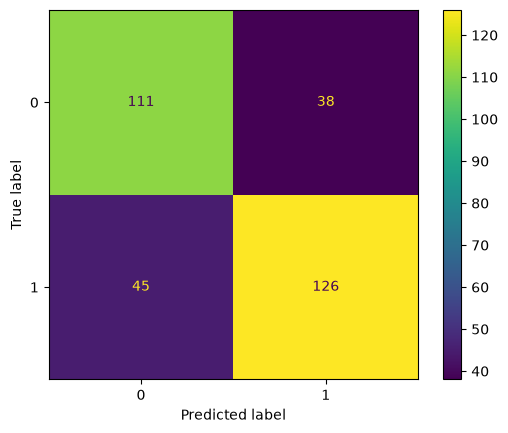

[[108  41]
 [ 38 133]]


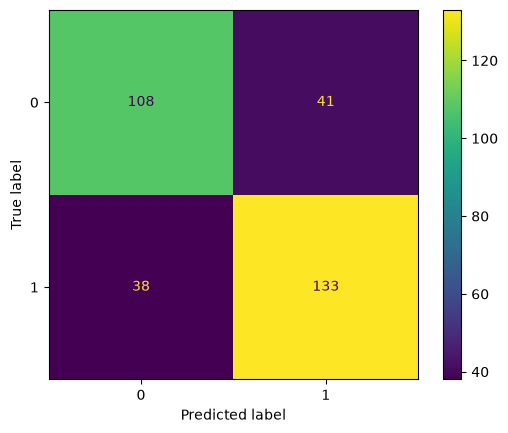

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Regressão Logística
cm = confusion_matrix(y_teste, prev1)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_teste, prev1)
plt.savefig("../results/figures/matriz_regressao.png")
plt.show()

# Árvore de Decisão
cm = confusion_matrix(y_teste, prev2)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_teste, prev2)
plt.savefig("../results/figures/matriz_arvore.png")
plt.show()


### Conclusão da Etapa 5 (classificação)

**Resultados obtidos:**

| Métrica | Regressão Logística | Árvore de Decisão |
|---|---|---|
| Acurácia | 0,741 | 0,753 |
| Precisão | 0,768 | 0,764 |
| Recall | 0,737 | 0,778 |
| F1-score | 0,752 | 0,771 |
| Gap treino-teste | 0,002 | 0,247 |

**Matrizes de confusão** (real x previsto, 0 = baixa, 1 = alta):

- Regressão Logística: `[[111, 38], [45, 126]]`
- Árvore de Decisão: `[[108, 41], [38, 133]]`


